In [3]:
import tifffile as tf
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from pathlib import Path
imgfile1 = Path('1-jumpCorrected-mc.tif')

In [5]:
def read_tiff_stack(filepath: str) -> np.ndarray:
    """
    Robustly read a TIFF stack as a 3D array (frames, height, width).
    
    Handles TIFFs that were written with chunked/contiguous writes which
    causes tifffile to split pages into multiple series. Falls back to
    reading all pages individually if series detection produces unexpected
    dimensions.
    
    Args:
        filepath: Path to TIFF file
        
    Returns:
        numpy array with shape (n_frames, height, width)
    """
    with tf.TiffFile(filepath) as tif:
        n_pages = len(tif.pages)
        
        # Check if simple read will work
        if len(tif.series) == 1:
            shape = tif.series[0].shape
            # If it's 3D (either multi-page or single-page with 3D data), use fast path
            if len(shape) == 3:
                return tif.asarray()
        
        # Multiple series (e.g., from chunked writes) - read all pages individually
        first_page = tif.pages[0].asarray()
        stack = np.zeros((n_pages, *first_page.shape), dtype=first_page.dtype)
        stack[0] = first_page
        for i, page in enumerate(tif.pages[1:], 1):
            stack[i] = page.asarray()
        
        return stack


In [6]:
img_green = read_tiff_stack(imgfile1)
img_green = img_green[::2,::2,::2]


In [7]:
img_red = read_tiff_stack(r'1-jumpCorrected-channel2-mc.tif')
img_red = img_red[::2,::2,::2]

In [8]:
img_red.shape

(3483, 208, 512)

In [9]:
def subtract_channel_leak(
    img_green: np.ndarray,
    img_red: np.ndarray,
    min_green_threshold: float = 100.0,
    max_scaling_factor: float = 2.0,
    smoothing_sigma: float = 0.0,
    use_percentile: bool = True,
    percentile: float = 99.0
) -> tuple[np.ndarray, np.ndarray]:
    """
    Subtract scaled green channel from red channel to reduce cross-channel leak.
    
    Calculates per-pixel scaling factors at peak green fluorescence for reliability,
    then subtracts: red_corrected = red - scaling * green
    
    Args:
        img_green: Green channel stack, shape (n_frames, height, width)
        img_red: Red channel stack, shape (n_frames, height, width). Must match green.
        min_green_threshold: Minimum green value at peak to compute reliable scaling.
                             Pixels with lower peak values use scaling=0 (no correction).
                             Default 100.0 (adjust based on your background level).
        max_scaling_factor: Maximum allowed scaling factor. Values above this are clipped
                            to prevent explosion artifacts. Default 2.0.
        smoothing_sigma: If > 0, apply Gaussian smoothing to the scaling map to reduce
                         noise. Default 0.0 (no smoothing).
        use_percentile: If True, use high percentile instead of max to find "peak".
                        More robust to noise spikes. Default True.
        percentile: Percentile to use when use_percentile=True. Default 99.0.
    
    Returns:
        Tuple of:
        - red_corrected: Corrected red channel (same shape as input), dtype float64
        - scaling_map: Per-pixel scaling factors used, shape (height, width)
    
    Example:
        >>> red_corrected, scaling = subtract_channel_leak(img_green, img_red)
        >>> # Visualize scaling map
        >>> plt.imshow(scaling, cmap='viridis')
        >>> plt.colorbar(label='Scaling factor')
        >>> # Compare before/after
        >>> fig, ax = plt.subplots(1, 2)
        >>> ax[0].imshow(img_red.mean(0), cmap='gray')
        >>> ax[1].imshow(red_corrected.mean(0), cmap='gray')
    
    Notes:
        - Background regions (low green) will have scaling=0, leaving red unchanged
        - The function handles division by zero and clips extreme ratios
        - For memory efficiency on large stacks, consider processing in chunks
    """
    if img_green.shape != img_red.shape:
        raise ValueError(f"Shape mismatch: green {img_green.shape} vs red {img_red.shape}")
    
    n_frames, height, width = img_green.shape
    
    # Convert to float64 for calculations
    green = img_green.astype(np.float64)
    red = img_red.astype(np.float64)
    
    # Find per-pixel peak frame indices for green channel
    if use_percentile:
        # Use high percentile for more robust peak detection
        green_peak_value = np.percentile(green, percentile, axis=0)
        # Find frames closest to this percentile value
        # Use argmax on a boolean mask near the percentile value
        threshold = green_peak_value * 0.99
        # Create mask of frames >= threshold, then find first occurrence
        above_threshold = green >= threshold[np.newaxis, :, :]
        # Use argmax to find first frame above threshold per pixel
        peak_frames = np.argmax(above_threshold, axis=0)
    else:
        # Simple argmax for peak frame
        peak_frames = np.argmax(green, axis=0)
    
    # Get values at peak frames using advanced indexing
    # peak_frames has shape (height, width)
    # We need to index: green[peak_frames[i,j], i, j] for each pixel
    row_idx, col_idx = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
    
    green_at_peak = green[peak_frames, row_idx, col_idx]
    red_at_peak = red[peak_frames, row_idx, col_idx]
    
    # Compute scaling factor: red/green at peak
    # Initialize with zeros (no correction for low-signal pixels)
    scaling_map = np.zeros((height, width), dtype=np.float64)
    
    # Only compute scaling where green is above threshold
    valid_mask = green_at_peak >= min_green_threshold
    scaling_map[valid_mask] = red_at_peak[valid_mask] / green_at_peak[valid_mask]
    
    # Clip to prevent explosion
    scaling_map = np.clip(scaling_map, 0, max_scaling_factor)
    
    # Handle negative scaling (shouldn't happen, but safety check)
    scaling_map[scaling_map < 0] = 0
    
    # Optionally smooth the scaling map to reduce noise
    if smoothing_sigma > 0:
        from scipy.ndimage import gaussian_filter as scipy_gaussian
        scaling_map = scipy_gaussian(scaling_map, sigma=smoothing_sigma)
    
    # Apply correction: red_corrected = red - scaling * green
    # Broadcasting: scaling_map (H, W) broadcasts with green (T, H, W)
    red_corrected = red - scaling_map[np.newaxis, :, :] * green
    
    # Clip to valid range (no negative values)
    red_corrected = np.maximum(red_corrected, 0)
    return red_corrected, scaling_map


Text(0.5, 1.0, 'Green (reference)')

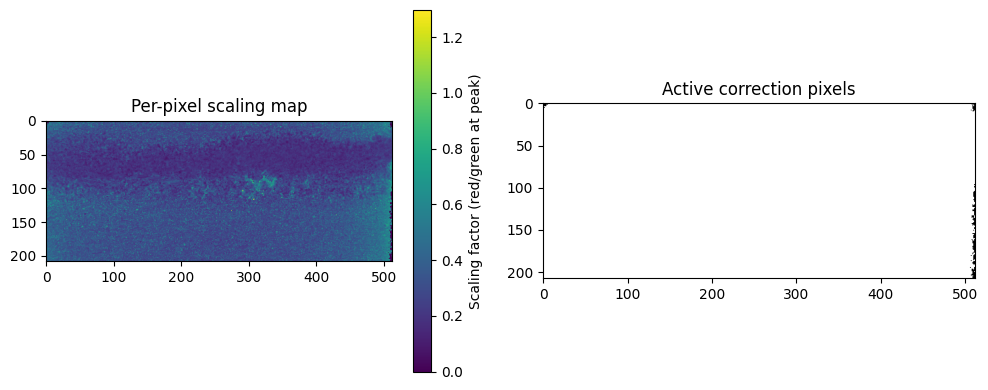

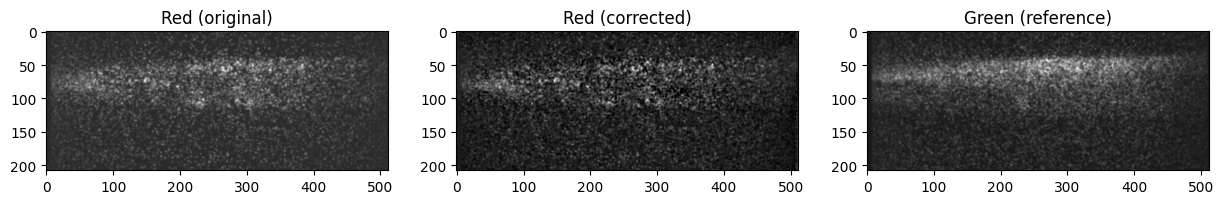

In [10]:
import sys 
sys.path.append('../../src')



# Basic usage
red_corrected, scaling_map = subtract_channel_leak(img_green, img_red,use_percentile=False)

# View the scaling map (shows where correction is applied)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(scaling_map, cmap='viridis')
plt.colorbar(label='Scaling factor (red/green at peak)')
plt.title('Per-pixel scaling map')

plt.subplot(1, 2, 2)
plt.imshow(scaling_map > 0, cmap='gray')
plt.title('Active correction pixels')
plt.tight_layout()

# Compare before/after
frame = 100
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(img_red[frame], cmap='gray')
ax[0].set_title('Red (original)')
ax[1].imshow(red_corrected[frame], cmap='gray')
ax[1].set_title('Red (corrected)')
ax[2].imshow(img_green[frame], cmap='gray')
ax[2].set_title('Green (reference)')

In [11]:
import napari

app = napari.Viewer()

In [12]:
from networkx.algorithms.bipartite import color
app.add_image(img_green,colormap='green',blending='Additive')
app.add_image(img_red,colormap='blue',blending='Additive')

app.add_image(red_corrected,colormap='red',blending='Additive')

<Image layer 'red_corrected' at 0x799b7402ae40>